In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import the necessary libraries

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [4]:
data.drop(columns=['Email No.'],inplace=True)

# drop the unnecessary column 

In [6]:
data.isnull().sum().sum()  # Check for missing values in the dataset

# check for missing values  

0

In [7]:
data.duplicated().sum()  # Check for duplicate rows in the dataset

541

In [8]:
data.drop_duplicates(inplace=True)  # Remove duplicate rows

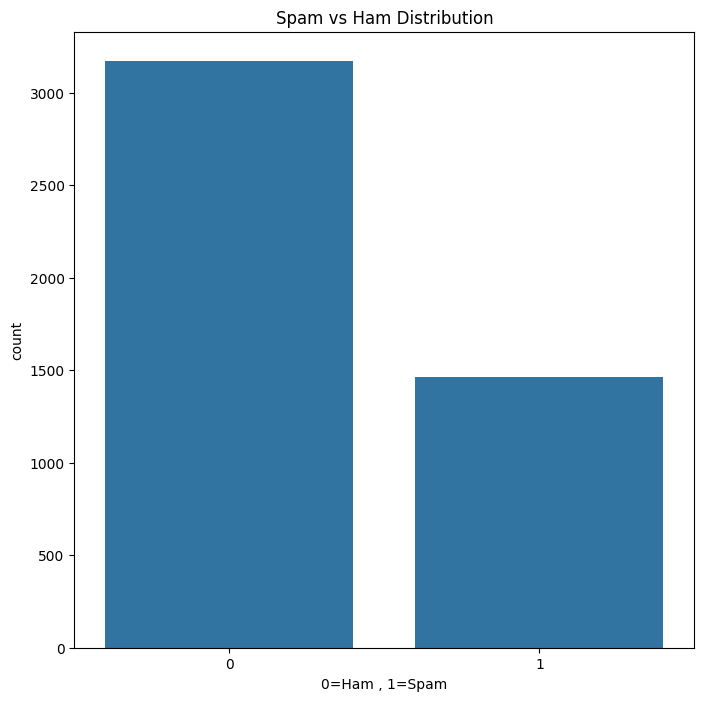

In [10]:
plt.figure(figsize=(8, 8))
sns.countplot(x='Prediction', data=data)
plt.title("Spam vs Ham Distribution")
plt.xlabel("0=Ham , 1=Spam")
plt.show()

# explore the data with countplot

In [11]:
x = data.drop(columns='Prediction',axis=1)
y = data['Prediction']

In [12]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42)

# split the data

In [13]:
from sklearn.ensemble import RandomForestClassifier

Model = RandomForestClassifier()
Model.fit(x_train,y_train)

# train the model

RandomForestClassifier()

In [14]:
y_pred = Model.predict(x_test)

 The Accuracy : 97.12%


Text(0.5, 1.0, 'Model Accuracy on Train and Test Sets')

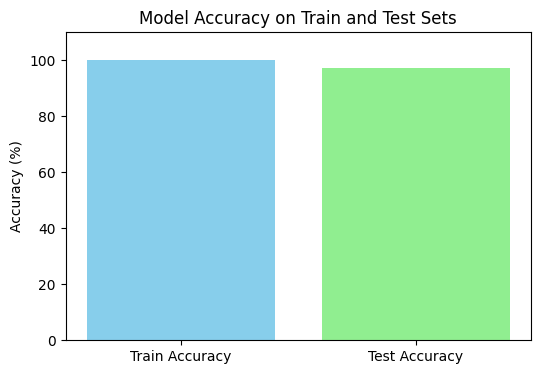

In [20]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f""" The Accuracy : {accuracy * 100:.2f}%""")

# print the accuracy of the model
train_score = accuracy_score(y_train, Model.predict(x_train)) * 100
test_score = accuracy_score(y_test, y_pred) * 100
plt.figure(figsize=(6, 4))
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_score, test_score], color=['skyblue', 'lightgreen'])
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy on Train and Test Sets')

output_dict=True: gives the report in a structured dictionary format.

pd.DataFrame(report).transpose(): makes it a readable table.

drop(['accuracy', 'macro avg', 'weighted avg']): optional to remove summary rows.

sns.heatmap(): visualizes the table in a colored format for easy comparison.

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       956
           1       0.94      0.97      0.95       434

    accuracy                           0.97      1390
   macro avg       0.96      0.97      0.97      1390
weighted avg       0.97      0.97      0.97      1390



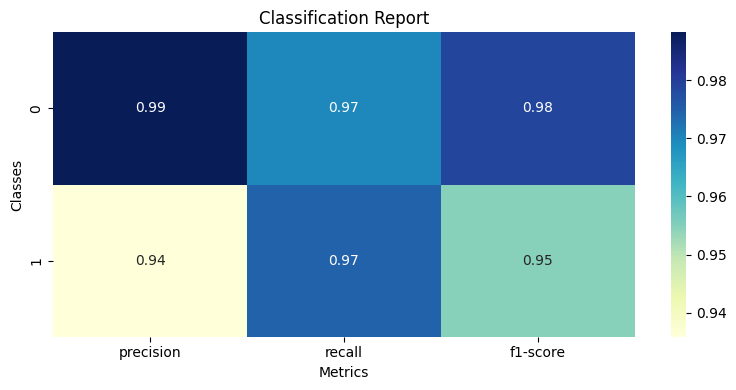

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
# print the classification report

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Generate classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert to pandas DataFrame (excluding 'accuracy' row)
report_df = pd.DataFrame(report).transpose().drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Plot the heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(report_df.iloc[:, :-1], annot=True, cmap="YlGnBu", fmt=".2f", cbar=True)

plt.title('Classification Report')
plt.ylabel('Classes')
plt.xlabel('Metrics')
plt.tight_layout()
plt.show()


In [18]:
# display the distribution of classes in y
print(y.value_counts())

Prediction
0    3170
1    1461
Name: count, dtype: int64


In [19]:
print(f"Train Score : {Model.score(x_train, y_train) * 100:.2f}%")
print(f"Test Score  : {Model.score(x_test, y_test) * 100:.2f}%")

# display training and test accuracy 

Train Score : 100.00%
Test Score  : 97.12%


In [23]:
from xgboost import XGBClassifier

model_xgboost = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model_xgboost.fit(x_train, y_train)


c:\Users\Mani\.conda\envs\tfod310\lib\site-packages\xgboost\training.py:183: UserWarning: [12:27:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
y_pred = model_xgboost.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 97.48%


In [26]:
from lightgbm import LGBMClassifier

model_LGBN = LGBMClassifier()
model_LGBN.fit(x_train, y_train)
y_pred = model_LGBN.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


[LightGBM] [Info] Number of positive: 1027, number of negative: 2214
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063842 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19257
[LightGBM] [Info] Number of data points in the train set: 3241, number of used features: 2357
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.316878 -> initscore=-0.768159
[LightGBM] [Info] Start training from score -0.768159
Accuracy: 97.70%


In [29]:
from catboost import CatBoostClassifier

model_catboost = CatBoostClassifier(verbose=0)
model_catboost.fit(x_train, y_train)
y_pred = model_catboost.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 97.99%


In [ ]:
# Save model to a .pkl file
import pickle
with open("catboost_model.pkl", "wb") as f:
    pickle.dump(model_catboost, f)